In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [2]:
df=pd.read_csv("/content/loan_dataset.csv")

In [3]:
!pip install xgboost

In [4]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [7]:
df.drop(columns="Loan_ID", axis=1, inplace=True)

In [8]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [9]:
df.isnull().sum()

,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14
Credit_History,50


In [10]:
df["Gender"].value_counts()

,count
Gender,
Male,489
Female,112


In [11]:
df["Married"].value_counts()

,count
Married,
Yes,398
No,213


In [12]:
df["Education"].value_counts()

,count
Education,
Graduate,480
Not Graduate,134


In [13]:
df["Self_Employed"].value_counts()

,count
Self_Employed,
No,500
Yes,82


In [ ]:
df["Loan_Amount_Term"].value_counts()

In [15]:
df["Credit_History"].value_counts()

,count
Credit_History,
1.0,475
0.0,89


In [16]:
df["Property_Area"].value_counts()

,count
Property_Area,
Semiurban,233
Urban,202
Rural,179


In [17]:
features_with_nan= [feature for feature in df.columns if df[feature].isnull().sum()>=1]
features_with_nan
for name in features_with_nan:
  print(f"{name}, {np.round(df[name].isnull().mean(),2)*100} % missing values")

Gender, 2.0 % missing values
Married, 0.0 % missing values
Dependents, 2.0 % missing values
Self_Employed, 5.0 % missing values
LoanAmount, 4.0 % missing values
Loan_Amount_Term, 2.0 % missing values
Credit_History, 8.0 % missing values


In [18]:
df[features_with_nan].select_dtypes(exclude="object").describe()

,LoanAmount,Loan_Amount_Term,Credit_History
count,592.000000,600.00000,564.000000
mean,146.412162,342.00000,0.842199
std,85.587325,65.12041,0.364878
min,9.000000,12.00000,0.000000
25%,100.000000,360.00000,1.000000
50%,128.000000,360.00000,1.000000
75%,168.000000,360.00000,1.000000
max,700.000000,480.00000,1.000000


In [21]:
## Mean Imputation
mean_list= ["Credit_History","LoanAmount"]
mode_list=["Gender","Married","Self_Employed","Dependents"]
median_list=["Loan_Amount_Term"]
for features in features_with_nan:
  if features in mean_list:
    df[features]=df[features].fillna(df[features].mean())
  elif features in mode_list:
    print(f"Performing Mode Impuation on {features}")
    df[features]=df[features].fillna(df[features].mode()[0])
  else:
    print(f"Performing Median Impuation on {features}")
    df[features]=df[features].fillna(df[features].median())

Performing Mode Impuation on Gender
Performing Mode Impuation on Married
Performing Mode Impuation on Dependents
Performing Mode Impuation on Self_Employed
Performing Median Impuation on Loan_Amount_Term


In [22]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,146.412162,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.000000,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.000000,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.000000,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.000000,360.0,1.0,Urban,Y


In [23]:
df.isnull().sum()

,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0
Credit_History,0


<Axes: >

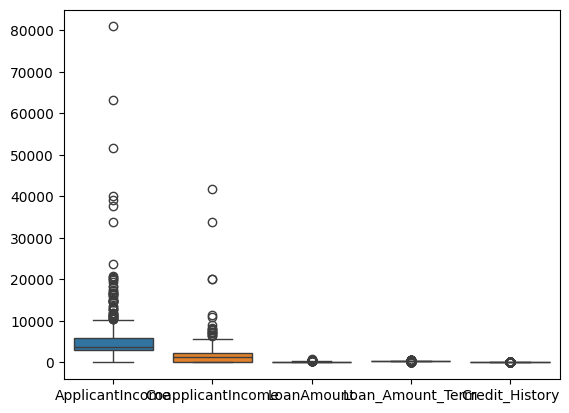

In [24]:
sns.boxplot(df)

In [26]:
df["Loan_Status"].value_counts()

,count
Loan_Status,
Y,422
N,192


In [27]:
df["Loan_Status"]=df["Loan_Status"].apply(lambda x: 1 if x=="Y" else 0)

In [29]:
df["Loan_Status"]=df["Loan_Status"].astype(int)

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             614 non-null    object 
 1   Married            614 non-null    object 
 2   Dependents         614 non-null    object 
 3   Education          614 non-null    object 
 4   Self_Employed      614 non-null    object 
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         614 non-null    float64
 8   Loan_Amount_Term   614 non-null    float64
 9   Credit_History     614 non-null    float64
 10  Property_Area      614 non-null    object 
 11  Loan_Status        614 non-null    int64  
dtypes: float64(4), int64(2), object(6)
memory usage: 57.7+ KB


In [35]:
df["Dependents"].value_counts()

,count
Dependents,
0,360
1,102
2,101
3+,51


In [36]:
df["Dependents"]=df["Dependents"].str.replace("3+","3")

In [37]:
df["Dependents"].value_counts()

,count
Dependents,
0,360
1,102
2,101
3,51


In [38]:
df["Dependents"]= df["Dependents"].astype(int)

In [39]:
cat_features= [feat for feat in df.columns if df[feat].dtype=="O"]
cat_features

['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area']

In [40]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,146.412162,360.0,1.0,Urban,1
1,Male,Yes,1,Graduate,No,4583,1508.0,128.000000,360.0,1.0,Rural,0
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.000000,360.0,1.0,Urban,1
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.000000,360.0,1.0,Urban,1
4,Male,No,0,Graduate,No,6000,0.0,141.000000,360.0,1.0,Urban,1


In [41]:
X=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [44]:
from sklearn.preprocessing import StandardScaler , OneHotEncoder
from sklearn.compose import ColumnTransformer

cat_feat= X.select_dtypes(include="object").columns
print(cat_feat)
num_feat= X.select_dtypes(exclude="object").columns
print(num_feat)
cv= ColumnTransformer(transformers=[
    ("onehotencoder",OneHotEncoder(),cat_feat),
    ("standardscaler",StandardScaler(),num_feat)
])


Index(['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area'], dtype='object')
Index(['Dependents', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='object')


In [45]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.20, stratify=y, random_state=7)
print(X_train.shape,y_train.shape)

(491, 11) (491,)


In [46]:
X_train=cv.fit_transform(X_train)
X_test=cv.transform(X_test)

In [55]:
from sklearn.linear_model import LogisticRegression, RidgeClassifier, ElasticNet
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report,f1_score,precision_score, recall_score
models={
    "RandomForest": RandomForestClassifier(),
    "DecisionTreeClassifier": DecisionTreeClassifier(),
    "xgb": XGBClassifier(),
    "svm" : SVC(kernel="linear"),
    "ridge": RidgeClassifier(),
    "logistic": LogisticRegression()
}

for i in range(len(list(models))):
  name=list(models.keys())[i]
  model=list(models.values())[i]

  ## train on data
  model.fit(X_train,y_train)

  ## Predict
  y_train_pred= model.predict(X_train)
  y_test_pred=model.predict(X_test)

  ## Metrics
  train_metrics= {
      "Accuarcy_score": accuracy_score(y_train,y_train_pred),
      "f1_score ": f1_score(y_train,y_train_pred),
      "precision_score": precision_score(y_train,y_train_pred),
      "recall_score": recall_score(y_train,y_train_pred),
      #"classification_report": classification_report(y_train,y_train_pred)
  }
  test_metrics= {
      "Accuarcy_score": accuracy_score(y_test,y_test_pred),
      "f1_score ": f1_score(y_test,y_test_pred),
      "precision_score": precision_score(y_test,y_test_pred),
      "recall_score": recall_score(y_test,y_test_pred),
      #"classification_report": classification_report(y_test,y_test_pred)
  }

  ## Training Metrics
  print("="*50)
  print(f"Model Name:{name} \n {'='*60}")
  for name_met, val_met in train_metrics.items():
    print(f"{name_met} : {val_met}")
  print("="*50)
  print("Test Data Metrics")
  print("="*50)
  for name_met, val_met in train_metrics.items():
    print(f"{name_met} : {val_met}")
  print("="*50)

Model Name:RandomForest 
Accuarcy_score : 1.0
f1_score  : 1.0
precision_score : 1.0
recall_score : 1.0
Test Data Metrics
Accuarcy_score : 1.0
f1_score  : 1.0
precision_score : 1.0
recall_score : 1.0
Model Name:DecisionTreeClassifier 
Accuarcy_score : 1.0
f1_score  : 1.0
precision_score : 1.0
recall_score : 1.0
Test Data Metrics
Accuarcy_score : 1.0
f1_score  : 1.0
precision_score : 1.0
recall_score : 1.0
Model Name:xgb 
Accuarcy_score : 1.0
f1_score  : 1.0
precision_score : 1.0
recall_score : 1.0
Test Data Metrics
Accuarcy_score : 1.0
f1_score  : 1.0
precision_score : 1.0
recall_score : 1.0
Model Name:svm 
Accuarcy_score : 0.814663951120163
f1_score  : 0.8797886393659181
precision_score : 0.7928571428571428
recall_score : 0.9881305637982196
Test Data Metrics
Accuarcy_score : 0.814663951120163
f1_score  : 0.8797886393659181
precision_score : 0.7928571428571428
recall_score : 0.9881305637982196
Model Name:ridge 
Accuarcy_score : 0.8187372708757638
f1_score  : 0.8821192052980132
precision

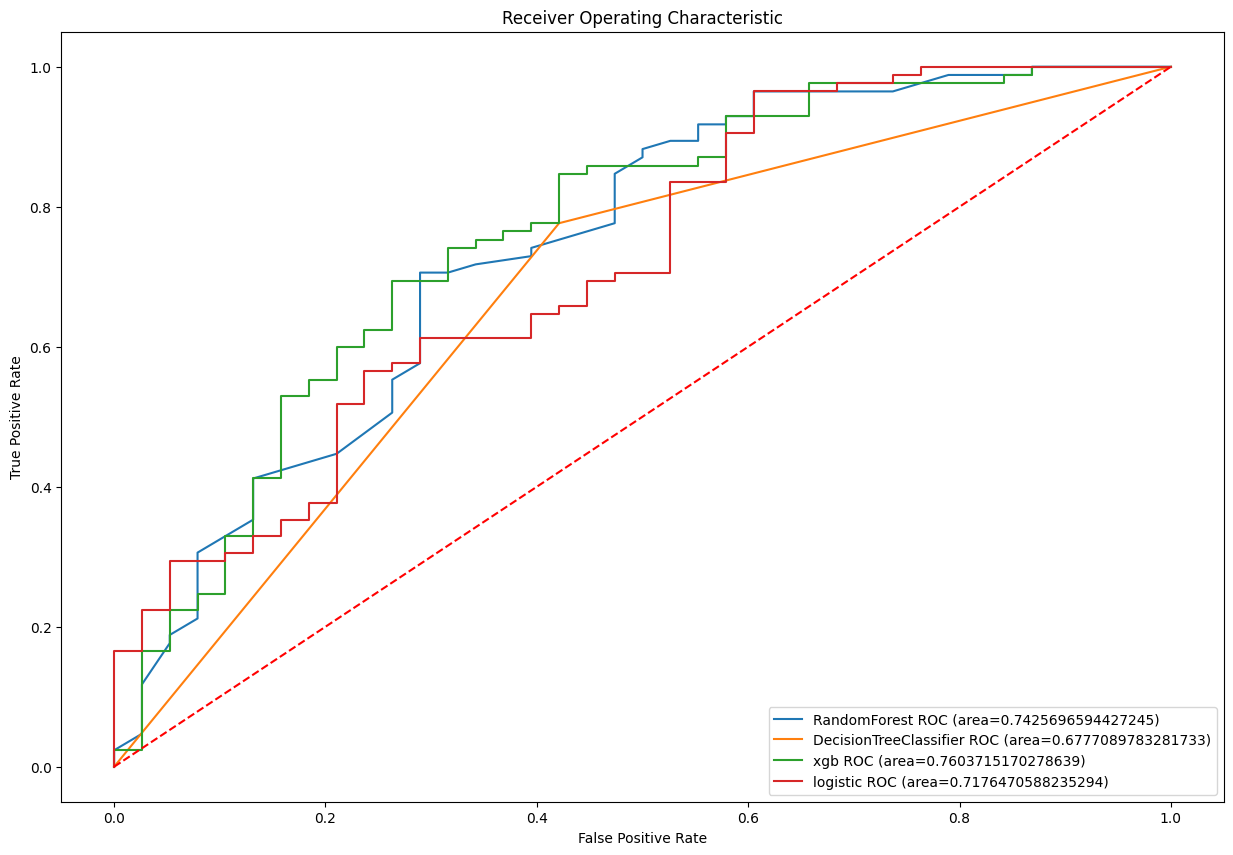

In [56]:
plt.figure(figsize=(15,10))
from sklearn.metrics import roc_auc_score, roc_curve
## assuming you have the roc and auc score values
for name, model in models.items():
  model=model.fit(X_train,y_train)
  if hasattr(model,"predict_proba"):
    y_test_score=model.predict_proba(X_test)[:,1]
    fpr,tpr, thresholds= roc_curve(y_test,y_test_score)
    plt.plot(fpr,tpr,label=f"{name} ROC (area={roc_auc_score(y_test,y_test_score)})")
plt.plot([0,1],[0,1],"r--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic")
plt.legend(loc="lower right")
plt.savefig("auc.png")
plt.show()